# Librerías y Funciones

In [66]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd
import os
from pathlib import Path
from scipy import stats as st
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import LogNorm


vec.register_awkward()

In [67]:
# Funciones

# Utilitary functions

def pi_formatter(x, pos):
    n = x / np.pi
    if np.isclose(n, 0):
        return r"$0$"
    if np.isclose(n, 1):
        return r"$\pi$"
    if np.isclose(n, -1):
        return r"$-\pi$"
    if n.is_integer():
        return rf"${int(n)}\pi$"
    return rf"${int(2*n)}\pi/2$"

def print_sample_info(Delphes, Energy_label, Total_events, time_of_flight, data_to_analyse):

    print("┌─────────────────────────────────────┐")
    print("│           SAMPLE INFORMATION        │")
    print("├─────────────────────────────────────┤")
    print(f"│ Delphes       : {Delphes:<20}│")
    print(f"│ Energy        : {Energy_label:<20}│")
    print(f"│ Total events  : {Total_events:<20}│")
    print(f"│ Time of flight: {time_of_flight:<20}│")
    print("├─────────────────────────────────────┤")
    print(f"│ Dataset       : {data_to_analyse:<20}│")
    print("└─────────────────────────────────────┘")

def parse_events(s):
    s = s.strip().lower()
    mult = {"k": 1_000, "M": 1_000_000}
    if s[-1] in mult:
        return int(float(s[:-1]) * mult[s[-1]])
    return int(s)

def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")

def vectors_buildup(data):
    jets = ak.zip({
        "pt": data["Jet.PT"],
        "eta": data["Jet.Eta"],
        "phi": data["Jet.Phi"],
        "mass": data["Jet.Mass"],
        'TauTag': data["Jet.TauTag"],
        'BTag': data["Jet.BTag"],
    }, with_name="Momentum4D")

    tracks = ak.zip({
        "pt": data["Track.PT"],
        "eta": data["Track.Eta"],
        "phi": data["Track.Phi"],
        "mass": data["Track.Mass"],
        "d0":  data["Track.D0"],  
        "dz":  data["Track.DZ"]
    }, with_name="Momentum4D")

    return jets, tracks

# Selection Functions

def MET_trigger(data, MET_lowerbond):

    MET_mask = ak.flatten(data["MissingET.MET"]) > MET_lowerbond

    return MET_mask

def preselection_cut(vec, Pt_lowerBond, Eta_absoluteBond):
    cinematic_mask = (vec.pt > Pt_lowerBond) & (abs(vec.eta) < Eta_absoluteBond)
    return cinematic_mask

def Selected_data(data, MET_LB, PT_LB_jets, Eta_AB_jets, PT_LB_tracks, Eta_AB_tracks):

    MET_mask = MET_trigger(data, MET_LB)

    data_selected = data[MET_mask]

    # Construyo los jets, con su cuadrivector y los BTag y tautag

    jets, tracks = vectors_buildup(data_selected)

    jets_preselected = preselection_cut(jets, PT_LB_jets, Eta_AB_jets)
    tracks_preselected = preselection_cut(tracks, PT_LB_tracks, Eta_AB_tracks)

    jets_select, tracks_select = jets[jets_preselected], tracks[tracks_preselected]

    return jets_select, tracks_select

def Taus_and_bjets(jets):
    taus = jets[(jets['TauTag'] == 1) & (jets['BTag'] == 0)]
    bjets = jets[(jets['TauTag'] == 0) & (jets['BTag'] == 1)]

    N_events = len(ak.sum(jets, axis=1))
    N_taus = ak.num(taus, axis=1)
    N_bjets = ak.num(bjets, axis=1)

    return taus, bjets, N_events, N_taus, N_bjets

def kinematic_hierarchical_order(taus, bjets):
    mask  = (ak.num(taus) >= 2) & (ak.num(bjets) >= 2)
    taus_cut, bjets_cut = taus[mask], bjets[mask]
    tau1, tau2 = taus_cut[:,0], taus_cut[:,1]
    b1, b2     = bjets_cut[:,0], bjets_cut[:,1]
    return tau1, tau2, b1, b2, taus_cut, bjets_cut

def PT_and_IM_of_products(tau1, tau2, b1, b2):
    M_tautau = (tau1+tau2).mass
    M_bb     = (b1+b2).mass
    M_hh     = (tau1+tau2+b1+b2).mass

    PT_tautau = (tau1+tau2).pt
    PT_bb     = (b1+b2).pt
    PT_hh     = (tau1+tau2+b1+b2).pt

    tuple_tautau = (M_tautau, PT_tautau)
    tuple_bb = (M_bb, PT_bb)
    tuple_hh = (M_hh, PT_hh)

    return tuple_tautau, tuple_bb, tuple_hh

# Data

In [68]:
common_path = "/home/usuario/Madgraph/projects/"

Delphes = "HL-LHC"
Energy_label = "14TeV"
Total_events = "100k"
time_of_flight = "-1"

data_to_analyse = f"{Delphes}_{Energy_label}_{Total_events}_TF{time_of_flight}"

rutas = {
    "signal": common_path + f"gg_hh-LQs/signal/Events/{data_to_analyse}_LQ/tag_1_delphes_events.root",
    # "background": common_path + f"gg_tth_hdecaylep/Events/{data_to_analyse}_BG_Htolep/tag_2_delphes_events.root",
    # "standardmodel": common_path + f"gg_hh-sm/Events/{data_to_analyse}_SM/tag_1_delphes_events.root"   
}

extracted_keys = ["Jet.PT","Jet.Eta", "Jet.Phi", "Jet.Mass", "Jet.BTag","Jet.TauTag", "MissingET.MET",
            'Track.PT', 'Track.Eta', 'Track.Phi', 'Track.Mass', 'Track.PID', 'Track.DZ', 'Track.D0', 'Track.Charge']

def data_loader(rutas):
    data = {}
    for key, path in rutas.items():
        data[key] = up.open(path)["Delphes"].arrays(extracted_keys)
    return data

all_data = data_loader(rutas)

folder_path = f'/home/usuario/VSCode/diHiggs-Project/RecAnalysis/{data_to_analyse}'

print_sample_info(Delphes, Energy_label, Total_events, time_of_flight, data_to_analyse)

N_events_text = parse_events(Total_events)

def check_events(expected, data):
    distintos = {k: len(v) for k, v in data.items() if len(v) != expected}
    if distintos:
        raise ValueError(f"Se esperaban {expected} eventos; difieren: {distintos}")
    print(f'All datasets contain: {expected} events')

N_events_text = parse_events(Total_events)

check_events(N_events_text, all_data)

os.makedirs(folder_path, exist_ok=True)

┌─────────────────────────────────────┐
│           SAMPLE INFORMATION        │
├─────────────────────────────────────┤
│ Delphes       : HL-LHC              │
│ Energy        : 14TeV               │
│ Total events  : 100k                │
│ Time of flight: -1                  │
├─────────────────────────────────────┤
│ Dataset       : HL-LHC_14TeV_100k_TF-1│
└─────────────────────────────────────┘
All datasets contain: 100000 events


# MET and Kinematic cuts

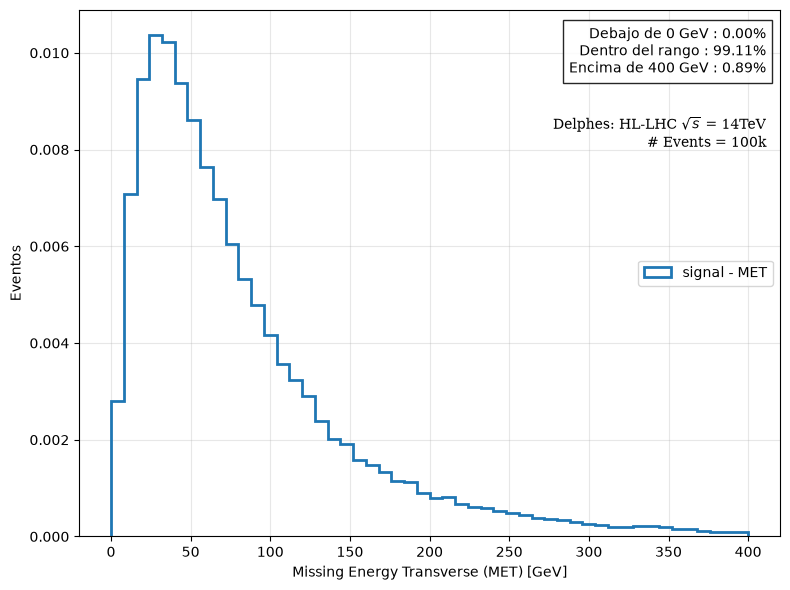

In [69]:
# Distribucion de MET, solo con corte de Cinemática

MET_data = {key: all_data[key]["MissingET.MET"] for key in all_data}

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(0,400, list(MET_data.values()))

Data_text_ID_precut = (fr"Delphes: {Delphes} " r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"# Events = {Total_events}")

plt.figure(figsize=(8,6))

texto = (f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"f"Dentro del rango : {p_dentro:.2f}%\n"f"Encima de {lim_sup} GeV : {p_encima:.2f}%")
plt.text(0.98, 0.97,texto,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

plt.text(0.98, 0.8, Data_text_ID_precut, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

for i, (key, MET) in enumerate(MET_data.items()):
        plt.hist(MET, bins=50, density=True, range=(lim_inf, lim_sup), histtype="step", linewidth=2, label=f"{key} - MET")

plt.xlabel(r"Missing Energy Transverse (MET) [GeV]")
plt.ylabel("Eventos")
plt.legend(loc = 'center right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{folder_path}/MET_distribution.png", dpi=300)
plt.show()

In [70]:
# Parámetros a definir

# [0, 20, 50, 70, 100, 150]

MET_LowerBond = 0     # GeV

# Jets preselection cuts
Pre_PT_jet = 20       # GeV
Pre_eta_jet = 2.5

# Tracks preselection cuts
Pre_PT_track = 0      # GeV
Pre_eta_track = 2.5


selected_data_folder_path_jets = f"{data_to_analyse}/Jets/MET{MET_LowerBond}_PT{Pre_PT_jet}_Eta{Pre_eta_jet}"
selected_data_folder_path_tracks = f"{data_to_analyse}/Tracks/MET{MET_LowerBond}_PT{Pre_PT_track}_Eta{Pre_eta_track}"

Data_text_ID_jets = ("Gen. Events: " f"{Total_events}" "\n"
                f"ToF: {time_of_flight}" "\n"
                fr"Delphes: {Delphes}" "\n"
                r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                fr"MET > {MET_LowerBond} GeV" "\n"
                fr"$p_T$ > {Pre_PT_jet} GeV" "\n"
                rf"$|\eta| < {Pre_eta_jet}$")

Data_text_ID_tracks = ("Gen. Events: " f"{Total_events}" "\n"
                    f"ToF: {time_of_flight}" "\n"
                    fr"Delphes: {Delphes}" "\n"
                    r"$\sqrt{s}$" f" = {Energy_label}" "\n"
                    fr"MET > {MET_LowerBond} GeV" "\n"
                    fr"$p_T$ > {Pre_PT_track} GeV" "\n"
                    rf"$|\eta| < {Pre_eta_track}$")


os.makedirs(selected_data_folder_path_jets, exist_ok=True)
os.makedirs(selected_data_folder_path_tracks, exist_ok=True)


def build_objects(data, MET_LowerBond, Pre_PT_jet, Pre_eta_jet, Pre_PT_track, Pre_eta_track):
    jets, tracks = {}, {}
    for key, d in data.items():
        jets[key], tracks[key] = Selected_data(d, MET_LowerBond, Pre_PT_jet, Pre_eta_jet,
                                               Pre_PT_track, Pre_eta_track)
    return jets, tracks

jets, tracks = build_objects(all_data, MET_LowerBond, Pre_PT_jet, Pre_eta_jet,
                             Pre_PT_track, Pre_eta_track)

# Tracks Analysis

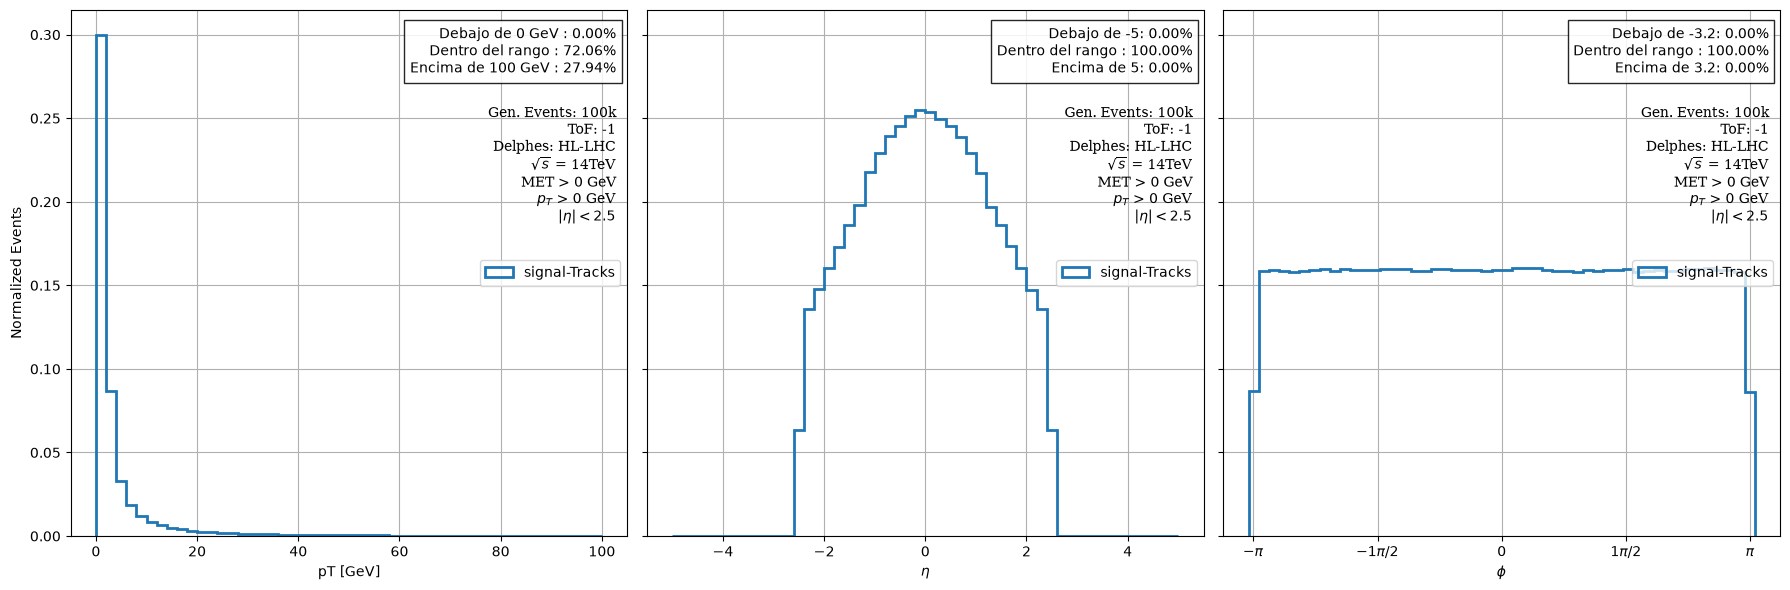

In [71]:
pt_data = {key: ak.to_numpy(ak.flatten(tracks[key].pt)) for key in tracks}
eta_data = {key: ak.to_numpy(ak.flatten(tracks[key].eta)) for key in tracks}
phi_data = {key: ak.to_numpy(ak.flatten(tracks[key].phi)) for key in tracks}

lim_inf_pt, lim_sup_pt, p_debajo_pt, p_dentro_pt, p_encima_pt = calculo_rangos(0, 100, list(MET_data.values()))
lim_inf_eta, lim_sup_eta, p_debajo_eta, p_dentro_eta, p_encima_eta = calculo_rangos(-5,5, list(eta_data.values()))
lim_inf_phi, lim_sup_phi, p_debajo_phi, p_dentro_phi, p_encima_phi = calculo_rangos(-3.2,3.2, list(phi_data.values()))

texto_pt = (f"Debajo de {lim_inf_pt} GeV : {p_debajo_pt:.2f}%\n"f"Dentro del rango : {p_dentro_pt:.2f}%\n"f"Encima de {lim_sup_pt} GeV : {p_encima_pt:.2f}%")
texto_eta = (f"Debajo de {lim_inf_eta}: {p_debajo_eta:.2f}%\n"f"Dentro del rango : {p_dentro_eta:.2f}%\n"f"Encima de {lim_sup_eta}: {p_encima_eta:.2f}%")
texto_phi = (f"Debajo de {lim_inf_phi}: {p_debajo_phi:.2f}%\n"f"Dentro del rango : {p_dentro_phi:.2f}%\n"f"Encima de {lim_sup_phi}: {p_encima_phi:.2f}%")

labels = [r"LQ - Tracks", r"BG - Tracks", r"SM - Tracks"]
kw = dict(bins=50, density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)


for i, (key, pt) in enumerate(pt_data.items()):
        axes[0].hist(pt, range=(lim_inf_pt, lim_sup_pt), **kw, label=f"{key}-Tracks")

for j, (key, eta) in enumerate(eta_data.items()):
        axes[1].hist(eta, range=(lim_inf_eta, lim_sup_eta), **kw, label=f"{key}-Tracks")

for k, (key, phi) in enumerate(phi_data.items()):
        axes[2].hist(phi, range=(lim_inf_phi, lim_sup_phi), **kw, label=f"{key}-Tracks")
        
axes[0].text(0.98, 0.97,texto_pt,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[0].set_ylabel("Normalized Events")
axes[0].set_xlabel("pT [GeV]")
axes[0].legend(loc = 'center right')

axes[1].text(0.98, 0.97,texto_eta,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].set_xlabel(r"$\eta$")
axes[1].legend(loc = 'center right')

axes[2].text(0.98, 0.97,texto_phi,transform=axes[2].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[2].xaxis.set_major_locator(MultipleLocator(np.pi / 2))
axes[2].xaxis.set_major_formatter(FuncFormatter(pi_formatter))
axes[2].set_xlabel(r"$\phi$")
axes[2].legend(loc = 'center right')

for ax in axes:
        ax.grid()
        ax.text(0.98, 0.82, Data_text_ID_tracks, transform=ax.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")


plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_tracks}/Tracks_distributions.png", dpi=300)
plt.show()


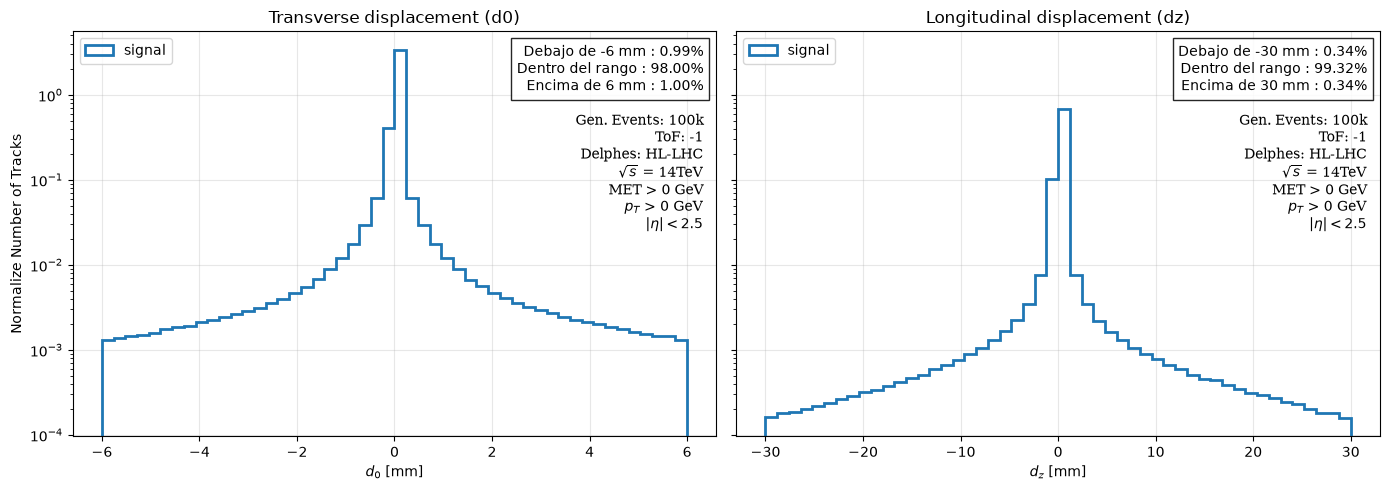

In [72]:
d0_data = {key: ak.to_numpy(ak.flatten(tracks[key].d0)) for key in tracks}
dz_data = {key: ak.to_numpy(ak.flatten(tracks[key].dz)) for key in tracks}

kw = dict(bins=50, density=True, histtype="step", linewidth=2)

lim_inf_d0, lim_sup_d0, p_debajo_d0, p_dentro_d0, p_encima_d0 = calculo_rangos(-6,6, list(d0_data.values()))
lim_inf_dz, lim_sup_dz, p_debajo_dz, p_dentro_dz, p_encima_dz = calculo_rangos(-30,30, list(dz_data.values()))

texto0 = (f"Debajo de {lim_inf_d0} mm : {p_debajo_d0:.2f}%\n"f"Dentro del rango : {p_dentro_d0:.2f}%\n"f"Encima de {lim_sup_d0} mm : {p_encima_d0:.2f}%")
texto1 = (f"Debajo de {lim_inf_dz} mm : {p_debajo_dz:.2f}%\n"f"Dentro del rango : {p_dentro_dz:.2f}%\n"f"Encima de {lim_sup_dz} mm : {p_encima_dz:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

axes[0].text(0.98, 0.97,texto0,transform=axes[0].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
axes[1].text(0.98, 0.97,texto1,transform=axes[1].transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

for i, (key, d0) in enumerate(d0_data.items()):
        axes[0].hist(d0, range=(lim_inf_d0, lim_sup_d0), **kw, label=f"{key}")

for j, (key, dz) in enumerate(dz_data.items()):
        axes[1].hist(dz, range=(lim_inf_dz, lim_sup_dz), **kw, label=f"{key}")

axes[0].set_xlabel(r"$d_0$ [mm]")
axes[0].set_ylabel("Normalize Number of Tracks")
axes[0].set_yscale('log')
axes[0].set_title('Transverse displacement (d0)')

axes[1].set_xlabel(r"$d_z$ [mm]")
axes[1].set_title('Longitudinal displacement (dz)')

for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(loc = 'upper left')
    ax.text(0.98, 0.8, Data_text_ID_tracks, transform=ax.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_tracks}/Vertex_displacement.png", dpi=300)
plt.show()

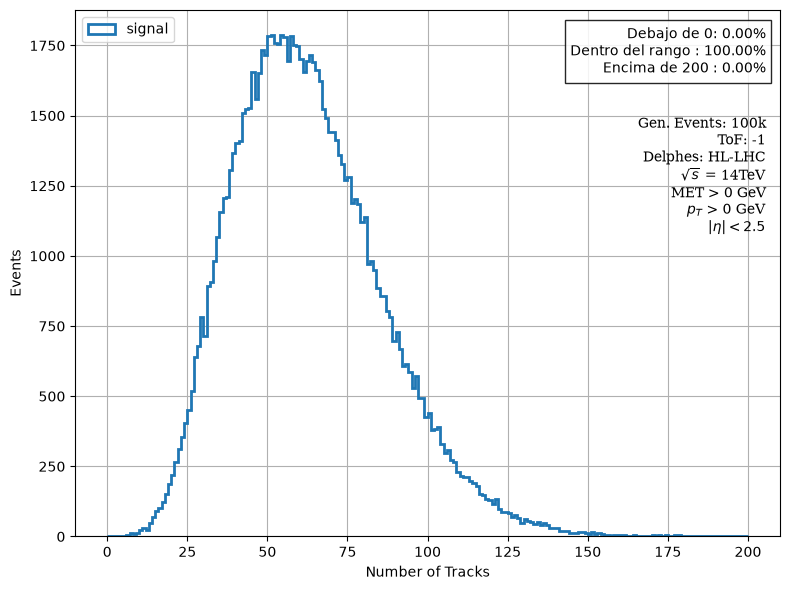

In [73]:
# Numero de Tracks por evento

ntrk_data = {key: ak.to_numpy(ak.num(tracks[key], axis=1)) for key in tracks}

lim_inf_ntrk, lim_sup_ntrk, p_debajo_ntrk, p_dentro_ntrk, p_encima_ntrk = calculo_rangos(0,200, list(ntrk_data.values()))

texto0 = (f"Debajo de {lim_inf_ntrk}: {p_debajo_ntrk:.2f}%\n"f"Dentro del rango : {p_dentro_ntrk:.2f}%\n"f"Encima de {lim_sup_ntrk} : {p_encima_ntrk:.2f}%")

plt.figure(figsize=(8,6))

plt.text(0.98, 0.97,texto0,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))
plt.text(0.98, 0.8, Data_text_ID_tracks, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

for i, (key, ntrk) in enumerate(ntrk_data.items()):
        plt.hist(ntrk, bins=200, density=False, range=(lim_inf_ntrk, lim_sup_ntrk), histtype="step", linewidth=2, label=f"{key}")

plt.xlabel(r"Number of Tracks")
plt.ylabel("Events")
plt.grid()
plt.legend(loc = 'upper left')

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_tracks}/Number_of_Tracks.png", dpi=300)
plt.show()

# Jets Analysis

In [ ]:
def build_taus_and_bjets(jets_input):
    
    taus, bjets, NEvents, NTaus, NBjets = {}, {}, {}, {}, {}
    for key, d in jets_input.items():
        taus[key], bjets[key], NEvents[key], NTaus[key], NBjets[key] = Taus_and_bjets(d)
    return taus, bjets, NEvents, NTaus, NBjets

def build_selected_pairs(taus, bjets):
    out = {}
    for key in taus:
        t1, t2, bb1, bb2, tc, bc = kinematic_hierarchical_order(taus[key], bjets[key])
        out[key] = {"tau1": t1, "tau2": t2, "b1": bb1, "b2": bb2,
                    "taus": tc, "bjets": bc}
    return out


def build_observables(sel):
    obs = {}
    for key, s in sel.items():
        t1, t2, bb1, bb2 = s["tau1"], s["tau2"], s["b1"], s["b2"]
        tup_tt, tup_bb, tup_hh = PT_and_IM_of_products(t1, t2, bb1, bb2)

        obs[key] = {
            "m_tautau": tup_tt[0],  "m_bb": tup_bb[0],  "m_hh": tup_hh[0],
            "pt_tautau": tup_tt[1], "pt_bb": tup_bb[1], "pt_hh": tup_hh[1],
            "dR_tautau": t1.deltaR(t2),
            "dR_bb":     bb1.deltaR(bb2),
        }
    return obs


taus, bjets, NEvents, NTaus, NBjets = build_taus_and_bjets(jets)    # Selecciono los Taus y Bs de cada Dataset
Selection_dictionary = build_selected_pairs(taus, bjets)            # Recorto a eventos con al menos 2 Taus y 2 Bs, y los ordeno por Pt
Observables = build_observables(Selection_dictionary)               # Calculo los observables de cada par de Taus y Bs seleccionados

ncols = len(Observables)


{'signal': {'m_tautau': <Array [124, 77.1, 120, 122, ..., 69.9, 77.7, 27.3, 61.8] type='2491 * float32'>, 'm_bb': <Array [679, 98.9, 103, 79.3, ..., 106, 62.2, 104, 108] type='2491 * float32'>, 'm_hh': <Array [981, 271, 387, 995, 197, ..., 818, 311, 346, 775] type='2491 * float32'>, 'pt_tautau': <Array [239, 33.7, 124, 578, ..., 257, 169, 108, 303] type='2491 * float32'>, 'pt_bb': <Array [228, 40.9, 143, 324, ..., 278, 114, 228, 467] type='2491 * float32'>, 'pt_hh': <Array [104, 19.4, 19.1, 282, ..., 247, 59.9, 145, 180] type='2491 * float32'>, 'dR_tautau': <Array [1.51, 2.44, 2.78, ..., 0.872, 0.571, 0.462] type='2491 * float32'>, 'dR_bb': <Array [4.17, 3.01, 1.54, 0.628, ..., 1.2, 0.868, 0.432] type='2491 * float32'>}}


In [75]:
etiquetas = {"signal": "Señal", "standardmodel": "Modelo Estándar", "background": "Fondo"}

def doubletag_events(j):
    dt = (j['TauTag'] == 1) & (j['BTag'] == 1)
    n_dt = int(ak.sum(ak.num(j[dt], axis=1) > 0))
    n_ev = len(j)
    return n_dt, 100 * n_dt / n_ev if n_ev else 0.0

lineas = [Data_text_ID_jets, ""]
lineas.append(f"{'Muestra':<18} {'Generados':>10} {'Pasan MET':>10} {'Acept. MET':>11} "
              f"{'Sel. 2t+2b':>11} {'Acept.':>8} {'Acept. tot.':>12} "
              f"{'Ev. doble tag':>14} {'% doble':>8}")
lineas.append("-" * 112)

for key in all_data:
    n_gen = len(all_data[key])
    n_met = len(jets[key])
    n_sel = len(Selection_dictionary[key]["taus"])

    acc_met = 100 * n_met / n_gen if n_gen else 0.0
    acc_sel = 100 * n_sel / n_met if n_met else 0.0
    acc_tot = 100 * n_sel / n_gen if n_gen else 0.0

    n_dt, pct_dt = doubletag_events(jets[key])

    lineas.append(f"{key:<18} {n_gen:>10} {n_met:>10} {acc_met:>10.2f}% "
                  f"{n_sel:>11} {acc_sel:>7.2f}% {acc_tot:>11.2f}% "
                  f"{n_dt:>14} {pct_dt:>7.2f}%")

texto = "\n".join(lineas)
print(texto)
_ = (Path(selected_data_folder_path_jets) / "cutflow.txt").write_text(texto + "\n")

Gen. Events: 100k
ToF: -1
Delphes: HL-LHC
$\sqrt{s}$ = 14TeV
MET > 0 GeV
$p_T$ > 20 GeV
$|\eta| < 2.5$

Muestra             Generados  Pasan MET  Acept. MET  Sel. 2t+2b   Acept.  Acept. tot.  Ev. doble tag  % doble
----------------------------------------------------------------------------------------------------------------
signal                 100000     100000     100.00%        2491    2.49%        2.49%           6848    6.85%


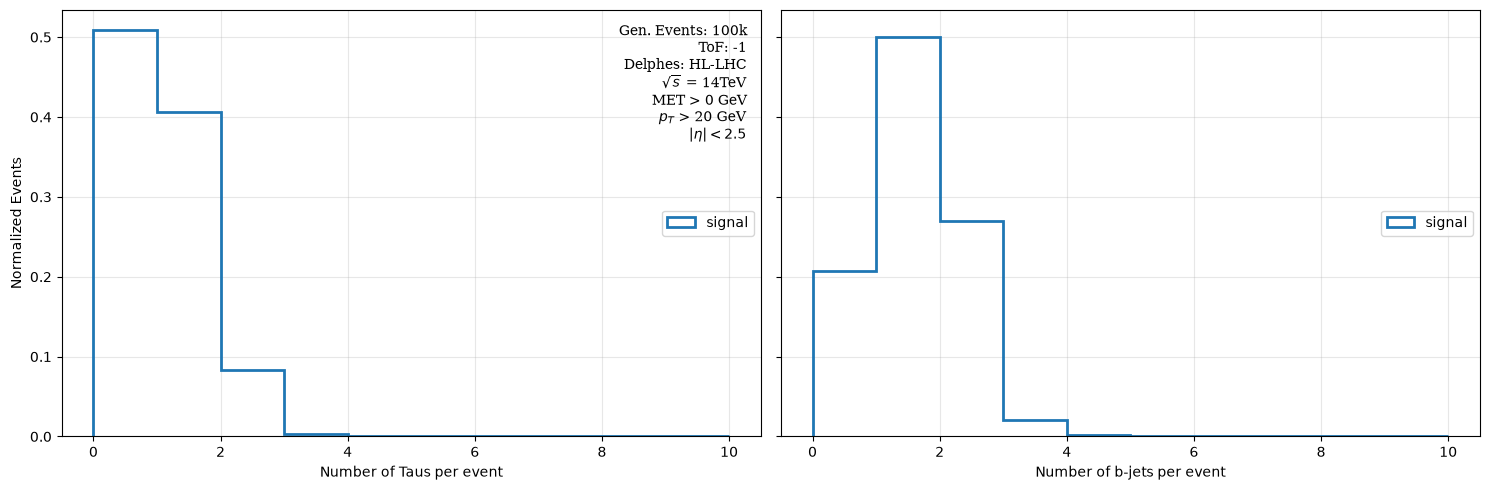

In [76]:
lim_inf_Ntaus, lim_sup_Ntaus, p_debajo_Ntaus, p_dentro_Ntaus, p_encima_Ntaus = calculo_rangos(0, 10, list(NTaus.values()))
lim_inf_Nbjets, lim_sup_Nbjets, p_debajo_Nbjets, p_dentro_Nbjets, p_encima_Nbjets = calculo_rangos(0, 10, list(NBjets.values()))

texto_Ntaus = (f"Debajo de {lim_inf_Ntaus} GeV : {p_debajo_Ntaus:.2f}%\n"f"Dentro del rango : {p_dentro_Ntaus:.2f}%\n"f"Encima de {lim_sup_Ntaus} GeV : {p_encima_Ntaus:.2f}%")
texto_Nbjets = (f"Debajo de {lim_inf_Nbjets} GeV : {p_debajo_Nbjets:.2f}%\n"f"Dentro del rango : {p_dentro_Nbjets:.2f}%\n"f"Encima de {lim_sup_Nbjets} GeV : {p_encima_Nbjets:.2f}%")

kw = dict(bins=10, density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, 2, figsize=(15,5), sharey=True)

axes[0].text(0.98, 0.97, Data_text_ID_jets, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

for key, arr in NTaus.items():
    axes[0].hist(ak.to_numpy(arr), range=(lim_inf_Ntaus, lim_sup_Ntaus), **kw, label=key)
    
axes[0].set_xlabel(r"Number of Taus per event")
axes[0].set_ylabel("Normalized Events")
axes[0].legend(loc = "center right")
axes[0].grid(alpha=0.3)

for key, arr in NBjets.items():
    axes[1].hist(ak.to_numpy(arr), range=(lim_inf_Nbjets, lim_sup_Nbjets), **kw, label=key)
axes[1].set_xlabel(r"Number of b-jets per event")
axes[1].legend(loc = "center right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_jets}/Taus&Bjets_in_events.png", dpi=300)
plt.show()

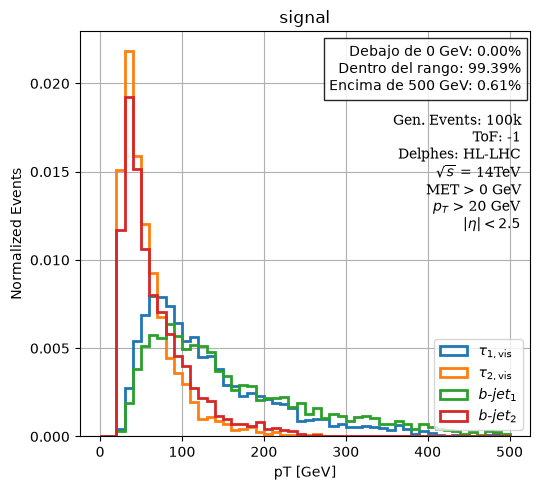

In [91]:
tau1_pt_data = {key: ak.to_numpy(Selection_dictionary[key]["tau1"].pt) for key in Selection_dictionary}
tau2_pt_data = {key: ak.to_numpy(Selection_dictionary[key]["tau2"].pt) for key in Selection_dictionary}
bjet1_pt_data = {key: ak.to_numpy(Selection_dictionary[key]["b1"].pt) for key in Selection_dictionary}
bjet2_pt_data = {key: ak.to_numpy(Selection_dictionary[key]["b2"].pt) for key in Selection_dictionary}

pt_all = {key: [tau1_pt_data[key],tau2_pt_data[key],bjet1_pt_data[key],bjet2_pt_data[key]]
          for key in Selection_dictionary}

rangos = {key: calculo_rangos(0, 500, pt_all[key]) for key in pt_all}

textos_rangos_pt = {}
for key, (li, ls, p_deb, p_den, p_enc) in rangos.items():
    textos_rangos_pt[key] = (f"Debajo de {li} GeV: {p_deb:.2f}%\n"
                   f"Dentro del rango: {p_den:.2f}%\n"
                   f"Encima de {ls} GeV: {p_enc:.2f}%")
    
labels = [r"$\tau_{1, \text{vis}}$", r"$\tau_{2, \text{vis}}$", r"$b\text{-}jet_1$", r"$b\text{-}jet_2$"]
kw = dict(bins=50, range=(0,500), density=True, histtype="step", linewidth=2)

fig, axes = plt.subplots(1, len(Observables.keys()), figsize=(5.5*ncols,5), sharey=True, squeeze=False)
axes = axes[0]
for i, (key) in enumerate(Selection_dictionary.keys()):
        axes[i].hist(tau1_pt_data[key], **kw, label=labels[0])
        axes[i].hist(tau2_pt_data[key], **kw, label=labels[1])
        axes[i].hist(bjet1_pt_data[key], **kw, label=labels[2])
        axes[i].hist(bjet2_pt_data[key], **kw, label=labels[3])
        axes[i].set_title(fr"{key}")
        axes[i].set_xlabel("pT [GeV]")
        axes[i].grid()
        axes[i].legend(loc = 'lower right')
        axes[i].text(0.98, 0.97, textos_rangos_pt[key], transform=axes[i].transAxes,
                ha="right", va="top", bbox=dict(facecolor="white", alpha=0.85))

axes[0].text(0.98, 0.8, Data_text_ID_jets, transform=axes[0].transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")
axes[0].set_ylabel("Normalized Events")

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_jets}/pt_distribution.png", dpi=300)
plt.show()

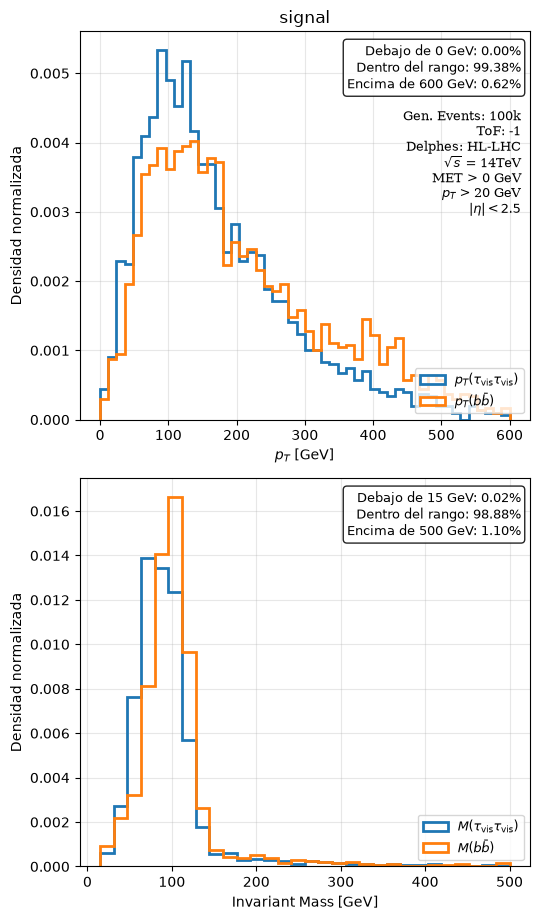

In [95]:
filas = [
    ("pt_tautau", "pt_bb", (0, 600),  50, r"$p_T$ [GeV]",
     r"$p_T(\tau_{\mathrm{vis}}\tau_{\mathrm{vis}})$", r"$p_T(b\bar{b})$"),
    ("m_tautau",  "m_bb",  (15, 500), 30, r"Invariant Mass [GeV]",
     r"$M(\tau_{\mathrm{vis}}\tau_{\mathrm{vis}})$", r"$M(b\bar{b})$"),
]

fig, axes = plt.subplots(2, len(Observables.keys()), figsize=(5.5*ncols, 10), sharey='row',squeeze=False)
for r, (k_tt, k_bb, (lo, hi), nbins, xlabel, lab_tt, lab_bb) in enumerate(filas):
    for c, key in enumerate(Observables):
        ax = axes[r, c]
        li, ls, p_deb, p_den, p_enc = calculo_rangos(lo, hi, [Observables[key][k_tt], Observables[key][k_bb]])

        kw = dict(bins=nbins, density=True, range=(li, ls), histtype="step", linewidth=2)
        ax.hist(ak.to_numpy(Observables[key][k_tt]), label=lab_tt, **kw)
        ax.hist(ak.to_numpy(Observables[key][k_bb]), label=lab_bb, **kw)

        ax.set_xlabel(xlabel)
        ax.legend(loc="lower right", fontsize=9)
        ax.grid(alpha=0.3)

        txt = (f"Debajo de {li} GeV: {p_deb:.2f}%\n"
               f"Dentro del rango: {p_den:.2f}%\n"
               f"Encima de {ls} GeV: {p_enc:.2f}%")
        ax.text(0.98, 0.97, txt, transform=ax.transAxes, ha="right", va="top",
                fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

        if r == 0:
            ax.set_title(fr'{key}')

axes[0, 0].set_ylabel("Densidad normalizada")
axes[1, 0].set_ylabel("Densidad normalizada")

axes[0, 0].text(0.98, 0.80, Data_text_ID_jets, transform=axes[0, 0].transAxes, ha="right", va="top",
         fontsize=9, family="DejaVu Serif")

fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(f"{selected_data_folder_path_jets}/pT_and_IM_pairs.png", dpi=300)
plt.show()

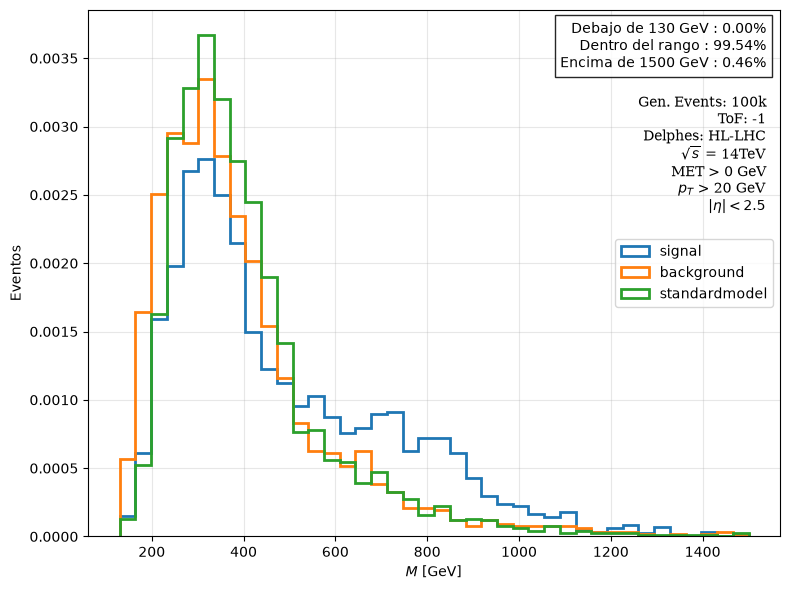

In [ ]:
Higgs_mass = {key: ak.to_numpy(Observables[key]["m_hh"]) for key in Observables}

lim_inf_mhh, lim_sup_mhh, p_debajo_mhh, p_dentro_mhh, p_encima_mhh = calculo_rangos(130,1500, list(Higgs_mass.values()))

texto_Higgs = (f"Debajo de {lim_inf_mhh} GeV : {p_debajo_mhh:.2f}%\n"f"Dentro del rango : {p_dentro_mhh:.2f}%\n"f"Encima de {lim_sup_mhh} GeV : {p_encima_mhh:.2f}%")

plt.figure(figsize=(8,6))

plt.text(0.98, 0.84, Data_text_ID_jets, transform=plt.gca().transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

plt.text(0.98, 0.98,texto_Higgs,transform=plt.gca().transAxes,ha="right",va="top",bbox=dict(facecolor="white", alpha=0.85))

for key, arr in Higgs_mass.items():
    plt.hist(ak.to_numpy(arr), bins=40, density=True, range=(lim_inf_mhh, lim_sup_mhh), histtype="step", linewidth=2, label=fr'{key}')

plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{selected_data_folder_path_jets}/InvariantMass_distribution.png", dpi=300)
plt.show()

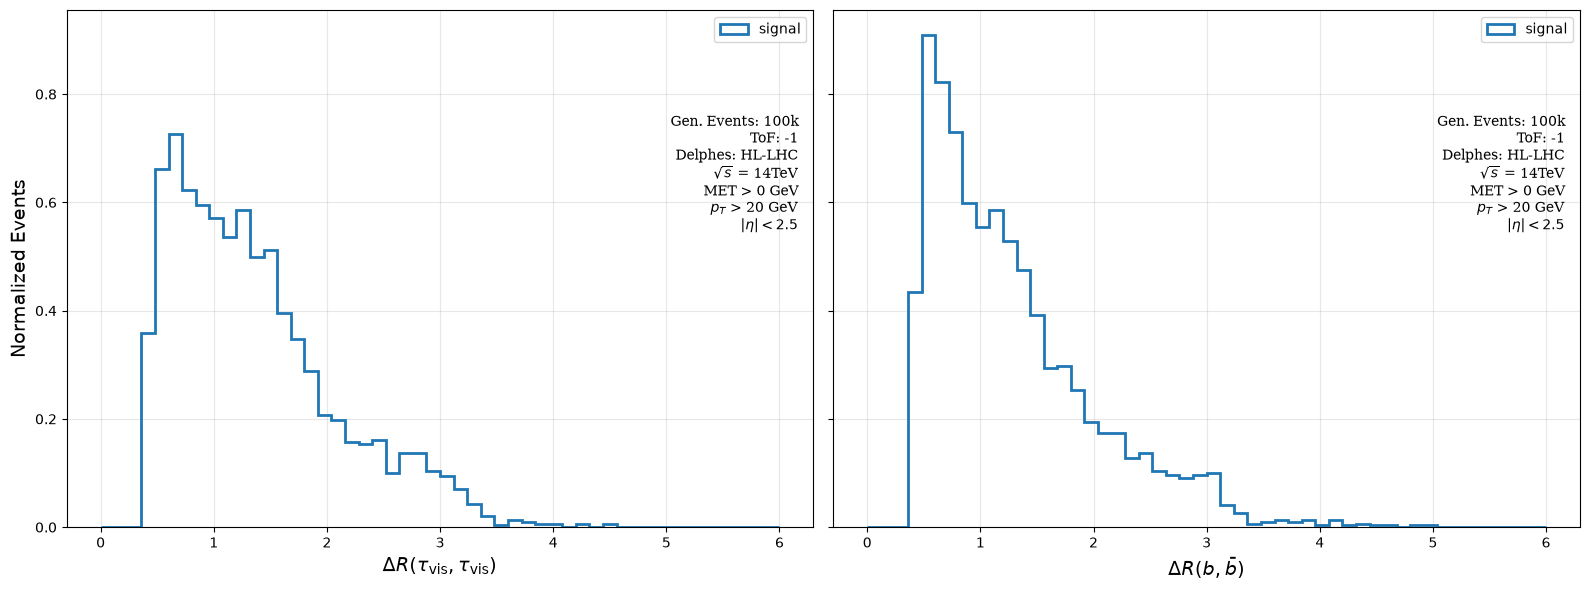

In [86]:
DeltaR_TT = {key: ak.to_numpy(Observables[key]["dR_tautau"]) for key in Observables}
DeltaR_BB = {key: ak.to_numpy(Observables[key]["dR_bb"]) for key in Observables}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6), sharey=True)

ax1.text(0.98, 0.80, Data_text_ID_jets, transform=ax1.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

ax2.text(0.98, 0.80, Data_text_ID_jets, transform=ax2.transAxes,
        ha="right", va="top", fontsize=10, family="DejaVu Serif")

kw = dict(bins=50,range=(0,6),histtype="step", density = True, linewidth=2)

# ==========================================================
# Primer gráfico
# ==========================================================

for key, arr in DeltaR_TT.items():
    ax1.hist(arr, **kw, label=fr"{key}")

ax1.set_xlabel(r"$\Delta R(\tau_{\text{vis}},\tau_{\text{vis}})$", fontsize=14)
ax1.set_ylabel("Normalized Events", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

for key, arr in DeltaR_BB.items():
    ax2.hist(arr, **kw, label=fr"{key}")

ax2.set_xlabel(r"$\Delta R(b,\bar{b})$", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig(f"{selected_data_folder_path_jets}/DeltaR_distribution.png", dpi=300)

plt.show()

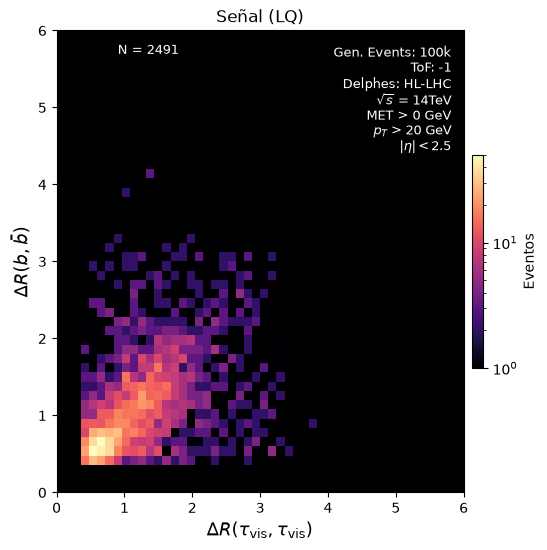

In [96]:
list_DeltaR_tautau = [DeltaR_TT[key] for key in DeltaR_TT]
list_DeltaR_bb = [DeltaR_BB[key] for key in DeltaR_BB]

etiquetas = ["Señal (LQ)", r"BG (gg > t$\bar{t}$h)", "SM"]

fig, axes = plt.subplots(1, len(Observables.keys()), figsize=(5.5*ncols, 6), sharex=True, sharey=True, squeeze=False)
axes = axes[0]
rango = [[0, 6], [0, 6]]
norm  = LogNorm(vmin=1, vmax=50)

for ax, name, dr_tt, dr_bb in zip(axes, etiquetas, list_DeltaR_tautau, list_DeltaR_bb):
    x = ak.to_numpy(dr_tt)
    y = ak.to_numpy(dr_bb)
    h = ax.hist2d(x, y, bins=50, range=rango, cmap="magma", norm=norm, cmin=1)
    ax.set_facecolor("black")
    ax.set_title(name, fontsize=12)
    ax.set_xlabel(r"$\Delta R(\tau_{\rm vis},\tau_{\rm vis})$", fontsize=13)
    ax.text(0.97, 0.97, Data_text_ID_jets, transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="white")
    ax.text(0.3, 0.97, f'N = {len(x)}', transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="white")

axes[0].set_ylabel(r"$\Delta R(b,\bar{b})$", fontsize=13)

fig.colorbar(h[3], ax=axes, label="Eventos", fraction=0.025, pad=0.02)

plt.savefig(f"{selected_data_folder_path_jets}/2D-DeltaR_por_muestra.png", dpi=300)
plt.show()